# 🧠 BCI Simulado: Señales Mentales Artificiales para Control Visual

## Objetivo del Taller
Simular el comportamiento de una interfaz cerebro-computadora (BCI) utilizando datos EEG artificiales para transformar señales en acciones visuales mediante procesamiento de señales y lógica de control simple.

## 📚 Conceptos Clave
- **EEG (Electroencefalografía)**: Medición de actividad eléctrica del cerebro
- **Bandas de Frecuencia**:
  - **Alpha (8-12 Hz)**: Asociada con relajación y atención
  - **Beta (12-30 Hz)**: Asociada con actividad mental y concentración
- **Procesamiento de Señales**: Filtrado y extracción de características
- **Control Visual**: Traducción de características en respuestas visuales

## 🎯 Flujo del Taller
1. Carga de datos EEG simulados
2. Visualización de la señal
3. Filtrado de bandas (Alpha y Beta)
4. Extracción de características
5. Lógica de control con umbrales
6. Respuesta visual interactiva
7. Dashboard interactivo

## 1️⃣ Importar Librerías Requeridas

En esta sección importamos todas las librerías necesarias para procesamiento de señales, análisis de datos y visualización.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import butter, lfilter, welch, hilbert
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo de gráficos
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

print("✅ Librerías importadas correctamente")
print(f"NumPy versión: {np.__version__}")
print(f"Pandas versión: {pd.__version__}")
print(f"SciPy versión: {signal.__version__ if hasattr(signal, '__version__') else 'N/A'}")

✅ Librerías importadas correctamente
NumPy versión: 2.3.5
Pandas versión: 2.3.3
SciPy versión: N/A


## 2️⃣ Generar y Cargar Datos EEG Simulados

Creamos un conjunto de datos EEG artificial que simula la actividad del cerebro con patrones realistas:
- **Señal base**: ruido gaussiano (simula EEG natural)
- **Componentes periódicas**: ondas Alpha (10 Hz) y Beta (20 Hz) moduladas
- **Artifacts**: picos de ruido ocasionales (simula movimientos)

**Estructura de datos:**
- Tiempo: duración de la grabación en segundos
- Amplitud: actividad eléctrica en microvolts (μV)
- Canales: múltiples electrodos EEG

In [2]:
# Parámetros de adquisición EEG
fs = 250  # Frecuencia de muestreo en Hz
duration = 30  # Duración de la grabación en segundos
num_samples = fs * duration  # Número total de muestras
t = np.arange(num_samples) / fs  # Vector de tiempo

print(f"⚙️ Parámetros de Adquisición:")
print(f"  - Frecuencia de muestreo: {fs} Hz")
print(f"  - Duración: {duration} segundos")
print(f"  - Muestras totales: {num_samples}")
print(f"  - Rango temporal: {t[0]:.2f} - {t[-1]:.2f} segundos")

# Generar señal EEG simulada con múltiples componentes
np.random.seed(42)  # Para reproducibilidad

# 1. Componente base: ruido gaussiano (EEG natural)
base_noise = np.random.normal(0, 10, num_samples)

# 2. Onda Alpha (8-12 Hz, asociada con relajación)
alpha_freq = 10  # Hz
alpha_component = 15 * np.sin(2 * np.pi * alpha_freq * t)
alpha_component *= (1 + 0.5 * np.sin(2 * np.pi * 0.1 * t))  # Modulación lenta

# 3. Onda Beta (12-30 Hz, asociada con actividad mental)
beta_freq = 20  # Hz
beta_component = 10 * np.sin(2 * np.pi * beta_freq * t)
beta_component *= (1 + 0.3 * np.sin(2 * np.pi * 0.2 * t))  # Modulación

# 4. Artefactos ocasionales (movimientos)
artifacts = np.zeros(num_samples)
for i in range(5):
    start_idx = np.random.randint(0, num_samples - 500)
    artifacts[start_idx:start_idx + 500] += np.random.normal(0, 30, 500)

# Combinar componentes
eeg_signal = base_noise + alpha_component + beta_component + artifacts

# Crear DataFrame con los datos
data = pd.DataFrame({
    'time': t,
    'amplitude': eeg_signal
})

print(f"\n✅ Datos EEG generados exitosamente")
print(f"\nEstructura de datos:")
print(data.head(10))
print(f"\nEstadísticas básicas:")
print(data['amplitude'].describe())

⚙️ Parámetros de Adquisición:
  - Frecuencia de muestreo: 250 Hz
  - Duración: 30 segundos
  - Muestras totales: 7500
  - Rango temporal: 0.00 - 30.00 segundos

✅ Datos EEG generados exitosamente

Estructura de datos:
    time  amplitude
0  0.000   4.967142
1  0.004   7.177194
2  0.008  22.190095
3  0.012  35.562630
4  0.016  19.489890
5  0.020  17.936277
6  0.024  32.140069
7  0.028  18.818163
8  0.032   1.216038
9  0.036   7.157862

Estadísticas básicas:
count    7500.000000
mean       -0.240481
std        23.685580
min      -160.659774
25%       -12.953133
50%        -0.279552
75%        12.830844
max       163.422882
Name: amplitude, dtype: float64


## 3️⃣ Visualizar la Señal EEG

La visualización de la señal permite observar:
- **Patrones temporales**: variaciones en amplitud a lo largo del tiempo
- **Componentes de frecuencia**: ondas de diferentes frecuencias superpuestas
- **Artefactos**: cambios abruptos o anomalías en la señal

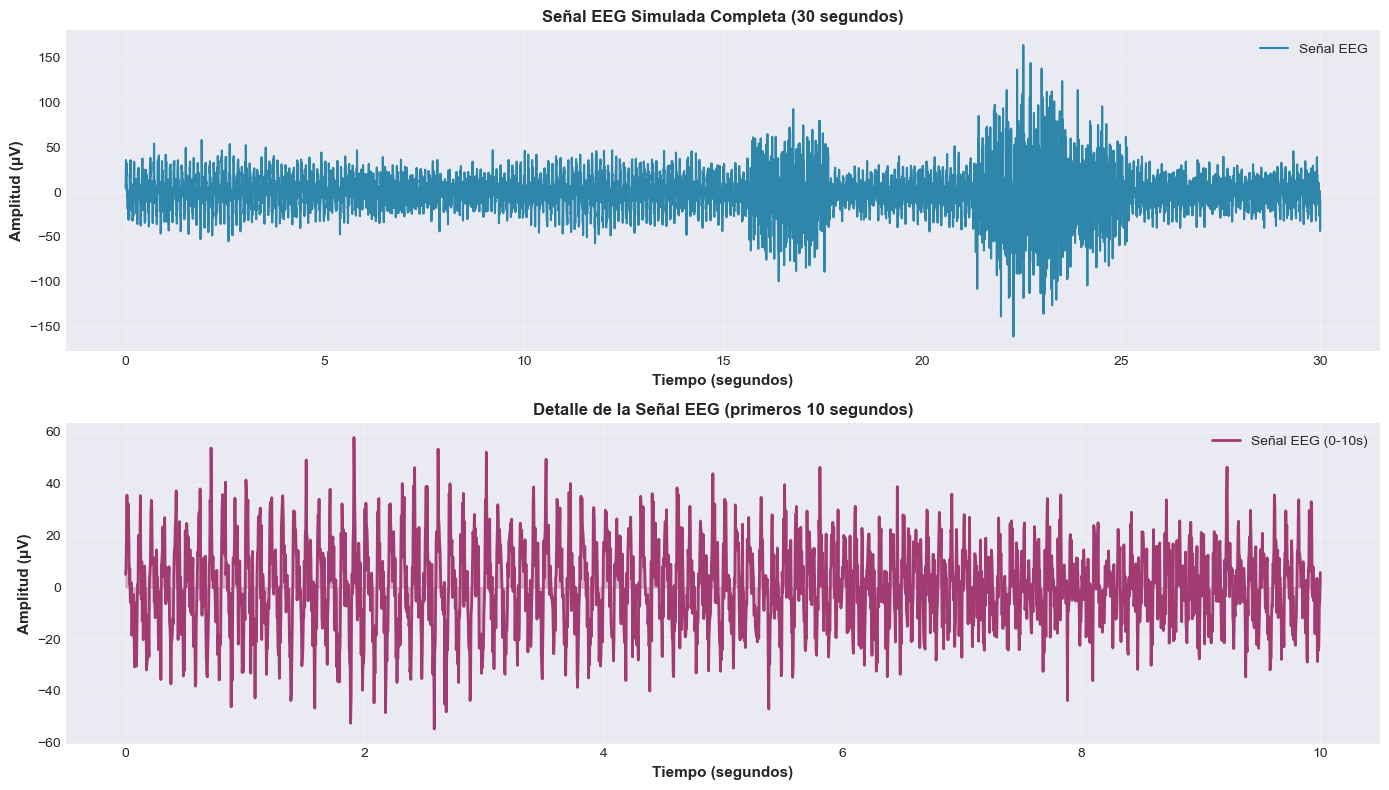

✅ Visualización de señal EEG completada


In [3]:
# Visualizar la señal EEG completa
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Gráfico 1: Señal EEG completa
axes[0].plot(data['time'], data['amplitude'], color='#2E86AB', linewidth=1.5, label='Señal EEG')
axes[0].set_xlabel('Tiempo (segundos)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Amplitud (μV)', fontsize=11, fontweight='bold')
axes[0].set_title('Señal EEG Simulada Completa (30 segundos)', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='upper right')

# Gráfico 2: Zoom en los primeros 10 segundos
time_limit = 10
mask = data['time'] <= time_limit
axes[1].plot(data[mask]['time'], data[mask]['amplitude'], color='#A23B72', linewidth=2, label='Señal EEG (0-10s)')
axes[1].fill_between(data[mask]['time'], data[mask]['amplitude'], alpha=0.3, color='#A23B72')
axes[1].set_xlabel('Tiempo (segundos)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Amplitud (μV)', fontsize=11, fontweight='bold')
axes[1].set_title('Detalle de la Señal EEG (primeros 10 segundos)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

print("✅ Visualización de señal EEG completada")

## 4️⃣ Análisis Espectral (Transformada de Fourier)

La **Transformada Rápida de Fourier (FFT)** nos permite convertir la señal del dominio del tiempo al dominio de la frecuencia. Esto es crucial para:
- Identificar las componentes de frecuencia dominantes
- Validar la presencia de ondas Alpha y Beta
- Localizar ruido y artefactos de alta frecuencia

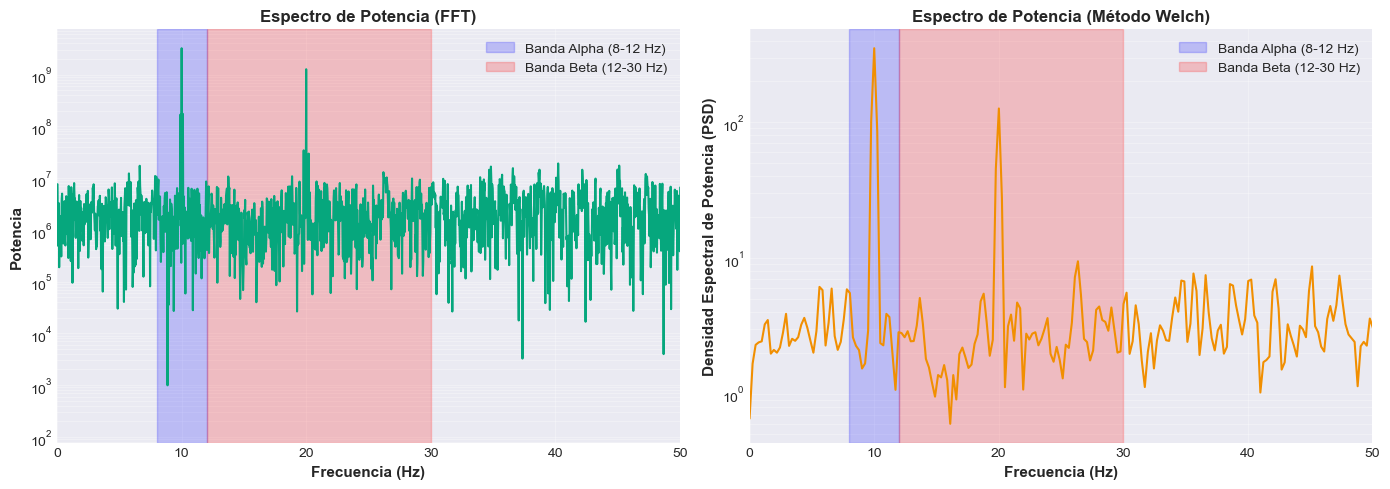

✅ Análisis espectral completado


In [4]:
# Calcular FFT de la señal
fft_values = np.fft.fft(data['amplitude'].values)
fft_freq = np.fft.fftfreq(len(fft_values), 1/fs)
power = np.abs(fft_values)**2  # Potencia

# Mantener solo frecuencias positivas
positive_freq_idx = fft_freq > 0
fft_freq_pos = fft_freq[positive_freq_idx]
power_pos = power[positive_freq_idx]

# Usar método de Welch para estimación más robusta
frequencies_welch, psd_welch = welch(data['amplitude'].values, fs=fs, nperseg=1024)

# Visualizar espectro de potencia
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Espectro de potencia FFT
axes[0].semilogy(fft_freq_pos, power_pos, color='#06A77D', linewidth=1.5)
axes[0].axvspan(8, 12, alpha=0.2, color='blue', label='Banda Alpha (8-12 Hz)')
axes[0].axvspan(12, 30, alpha=0.2, color='red', label='Banda Beta (12-30 Hz)')
axes[0].set_xlabel('Frecuencia (Hz)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Potencia', fontsize=11, fontweight='bold')
axes[0].set_title('Espectro de Potencia (FFT)', fontsize=12, fontweight='bold')
axes[0].set_xlim(0, 50)
axes[0].grid(True, alpha=0.3, which='both')
axes[0].legend()

# Espectro de potencia Welch
axes[1].semilogy(frequencies_welch, psd_welch, color='#F18F01', linewidth=1.5)
axes[1].axvspan(8, 12, alpha=0.2, color='blue', label='Banda Alpha (8-12 Hz)')
axes[1].axvspan(12, 30, alpha=0.2, color='red', label='Banda Beta (12-30 Hz)')
axes[1].set_xlabel('Frecuencia (Hz)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Densidad Espectral de Potencia (PSD)', fontsize=11, fontweight='bold')
axes[1].set_title('Espectro de Potencia (Método Welch)', fontsize=12, fontweight='bold')
axes[1].set_xlim(0, 50)
axes[1].grid(True, alpha=0.3, which='both')
axes[1].legend()

plt.tight_layout()
plt.show()

print("✅ Análisis espectral completado")

## 5️⃣ Aplicar Filtrado de Banda (Band-Pass Filtering)

Los **filtros pasa banda** permiten aislar rangos de frecuencia específicos. Para BCI usamos:
- **Filtro Alpha (8-12 Hz)**: Aislamos la actividad asociada con relajación
- **Filtro Beta (12-30 Hz)**: Aislamos la actividad asociada con concentración

**Tipo de filtro**: Butterworth (orden 4) - balance entre suavidad y selectividad de frecuencia.
**Orden**: Número de polos del filtro (orden más alto = selectividad mayor)

**Ecuación del filtro Butterworth:**
$$H(f) = \frac{1}{\sqrt{1 + \left(\frac{f}{f_c}\right)^{2n}}}$$

donde $n$ es el orden y $f_c$ es la frecuencia de corte.

In [5]:
def bandpass_filter(signal_data, lowcut, highcut, fs, order=4):
    """
    Aplicar filtro pasa banda Butterworth
    
    Parámetros:
    - signal_data: Señal a filtrar
    - lowcut: Frecuencia de corte inferior (Hz)
    - highcut: Frecuencia de corte superior (Hz)
    - fs: Frecuencia de muestreo (Hz)
    - order: Orden del filtro
    
    Retorna:
    - Señal filtrada
    """
    nyquist_freq = fs / 2
    low = lowcut / nyquist_freq
    high = highcut / nyquist_freq
    
    # Diseñar filtro
    b, a = butter(order, [low, high], btype='band')
    
    # Aplicar filtro
    filtered_signal = lfilter(b, a, signal_data)
    
    return filtered_signal

# Parámetros de las bandas
alpha_low, alpha_high = 8, 12
beta_low, beta_high = 12, 30

# Aplicar filtros
eeg_alpha = bandpass_filter(data['amplitude'].values, alpha_low, alpha_high, fs)
eeg_beta = bandpass_filter(data['amplitude'].values, beta_low, beta_high, fs)

# Agregar señales filtradas al DataFrame
data['alpha_filtered'] = eeg_alpha
data['beta_filtered'] = eeg_beta

print("✅ Filtros aplicados exitosamente")
print(f"  - Filtro Alpha: {alpha_low}-{alpha_high} Hz")
print(f"  - Filtro Beta: {beta_low}-{beta_high} Hz")
print(f"\nEjemplos de datos filtrados:")
print(data[['time', 'amplitude', 'alpha_filtered', 'beta_filtered']].head(10))

✅ Filtros aplicados exitosamente
  - Filtro Alpha: 8-12 Hz
  - Filtro Beta: 12-30 Hz

Ejemplos de datos filtrados:
    time  amplitude  alpha_filtered  beta_filtered
0  0.000   4.967142        0.000028       0.007668
1  0.004   7.177194        0.000250       0.057459
2  0.008  22.190095        0.001193       0.223515
3  0.012  35.562630        0.004108       0.614520
4  0.016  19.489890        0.011206       1.276341
5  0.020  17.936277        0.025122       1.941627
6  0.024  32.140069        0.047629       1.963098
7  0.028  18.818163        0.078593       0.772015
8  0.032   1.216038        0.115367      -1.600404
9  0.036   7.157862        0.152240      -4.503834


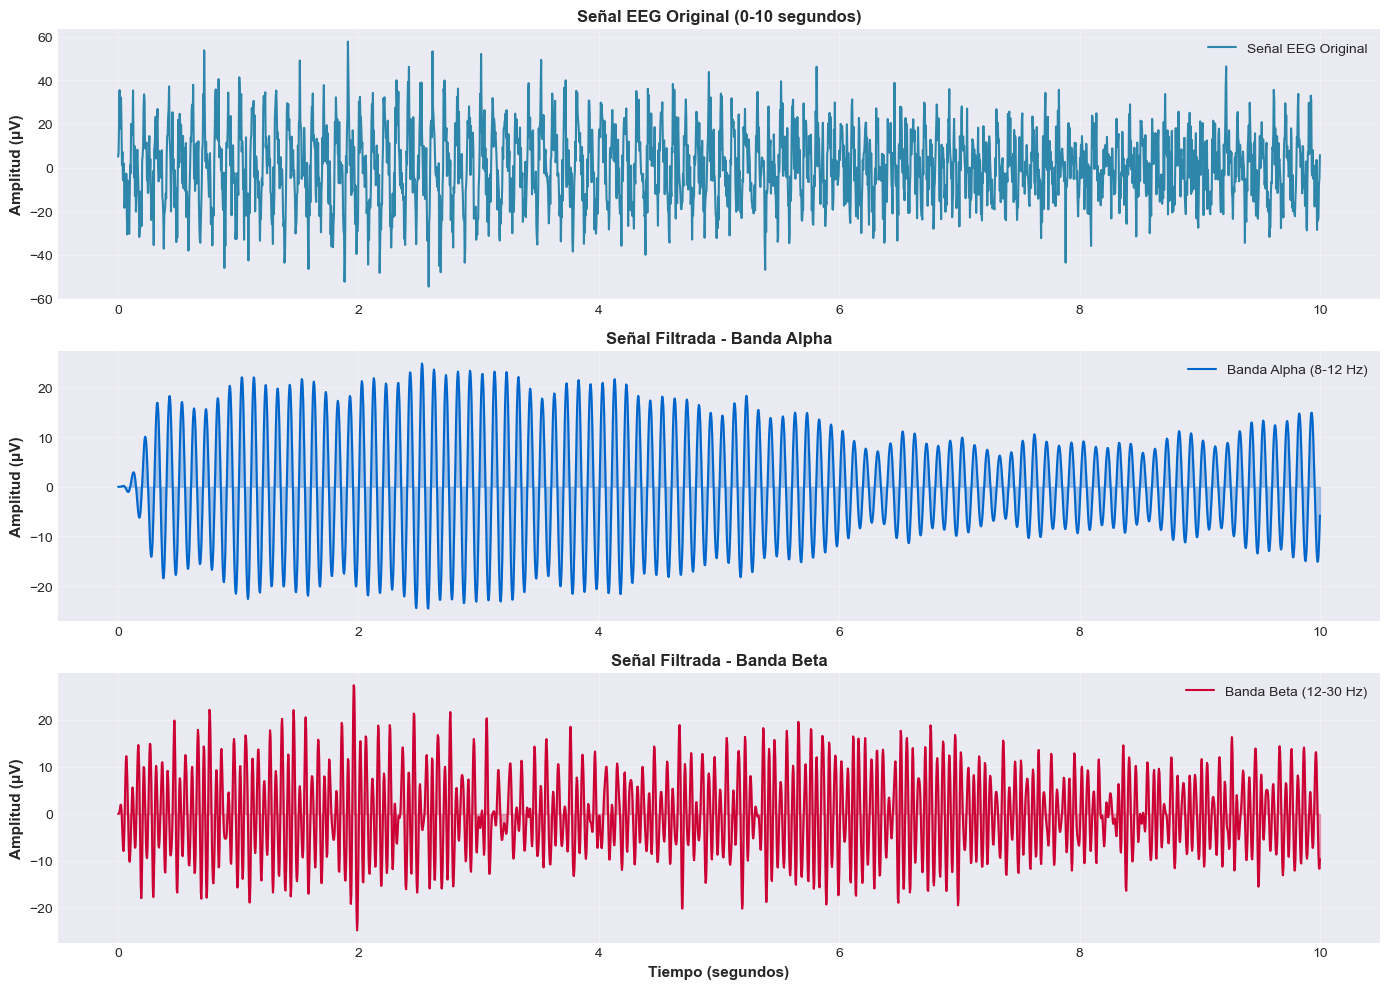

✅ Visualización de señales filtradas completada


In [6]:
# Visualizar señales filtradas (primeros 10 segundos)
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

time_limit = 10
mask = data['time'] <= time_limit

# Señal original
axes[0].plot(data[mask]['time'], data[mask]['amplitude'], 
             color='#2E86AB', linewidth=1.5, label='Señal EEG Original')
axes[0].set_ylabel('Amplitud (μV)', fontsize=11, fontweight='bold')
axes[0].set_title('Señal EEG Original (0-10 segundos)', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='upper right')

# Señal filtrada Alpha
axes[1].plot(data[mask]['time'], data[mask]['alpha_filtered'], 
             color='#0066CC', linewidth=1.5, label='Banda Alpha (8-12 Hz)')
axes[1].fill_between(data[mask]['time'], data[mask]['alpha_filtered'], 
                     alpha=0.3, color='#0066CC')
axes[1].set_ylabel('Amplitud (μV)', fontsize=11, fontweight='bold')
axes[1].set_title('Señal Filtrada - Banda Alpha', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='upper right')

# Señal filtrada Beta
axes[2].plot(data[mask]['time'], data[mask]['beta_filtered'], 
             color='#CC0033', linewidth=1.5, label='Banda Beta (12-30 Hz)')
axes[2].fill_between(data[mask]['time'], data[mask]['beta_filtered'], 
                     alpha=0.3, color='#CC0033')
axes[2].set_xlabel('Tiempo (segundos)', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Amplitud (μV)', fontsize=11, fontweight='bold')
axes[2].set_title('Señal Filtrada - Banda Beta', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].legend(loc='upper right')

plt.tight_layout()
plt.show()

print("✅ Visualización de señales filtradas completada")

## 6️⃣ Extracción de Características

Las características se extraen usando ventanas deslizantes (**windows**). Para cada ventana calculamos:
- **Potencia RMS (Root Mean Square)**: Energía de la señal en la ventana
- **Potencia (PSD - Power Spectral Density)**: Métodos Welch
- **Nivel de Atención**: Métrica combinada que refleja actividad cerebral

**Fórmula de RMS:**
$$\text{RMS} = \sqrt{\frac{1}{N}\sum_{i=1}^{N}x_i^2}$$

**Ventana**: División temporal de la señal en intervalos (ej: 1 segundo = 250 muestras)

In [7]:
def extract_features(signal_data, fs, window_size_sec=1):
    """
    Extraer características usando ventanas deslizantes
    
    Parámetros:
    - signal_data: Señal a procesar
    - fs: Frecuencia de muestreo
    - window_size_sec: Tamaño de ventana en segundos
    
    Retorna:
    - power_features: Potencia en cada ventana
    - time_windows: Tiempo correspondiente a cada ventana
    """
    window_size = int(fs * window_size_sec)  # Convertir a muestras
    num_windows = len(signal_data) // window_size
    
    power_features = []
    time_windows = []
    
    for i in range(num_windows):
        start_idx = i * window_size
        end_idx = (i + 1) * window_size
        window = signal_data[start_idx:end_idx]
        
        # Calcular potencia RMS
        rms_power = np.sqrt(np.mean(window**2))
        power_features.append(rms_power)
        
        # Tiempo central de la ventana
        time_window = (start_idx + end_idx) / (2 * fs)
        time_windows.append(time_window)
    
    return np.array(power_features), np.array(time_windows)

# Extraer características
window_size_sec = 1  # Ventana de 1 segundo
alpha_power, time_windows = extract_features(data['alpha_filtered'].values, fs, window_size_sec)
beta_power, _ = extract_features(data['beta_filtered'].values, fs, window_size_sec)

# Normalizar características
alpha_power_norm = (alpha_power - alpha_power.mean()) / alpha_power.std()
beta_power_norm = (beta_power - beta_power.mean()) / beta_power.std()

# Crear métrica de "Nivel de Atención"
# Alpha dominante = relajación, Beta dominante = concentración
attention_level = beta_power_norm - alpha_power_norm

# Crear DataFrame de características
features_df = pd.DataFrame({
    'time': time_windows,
    'alpha_power': alpha_power,
    'beta_power': beta_power,
    'alpha_norm': alpha_power_norm,
    'beta_norm': beta_power_norm,
    'attention_level': attention_level
})

print("✅ Características extraídas exitosamente")
print(f"  - Ventana temporal: {window_size_sec} segundo(s)")
print(f"  - Número de ventanas: {len(features_df)}")
print(f"\nEstadísticas de características:")
print(features_df[['alpha_power', 'beta_power', 'attention_level']].describe())

✅ Características extraídas exitosamente
  - Ventana temporal: 1 segundo(s)
  - Número de ventanas: 30

Estadísticas de características:
       alpha_power  beta_power  attention_level
count    30.000000   30.000000     3.000000e+01
mean     11.091385    9.552886     8.141636e-17
std       3.607459    2.869467     1.037160e+00
min       5.545019    6.155517    -2.065735e+00
25%       8.584452    7.295374    -4.978003e-01
50%      10.787482    8.954232     1.713279e-01
75%      14.298085   10.324918     6.179121e-01
max      18.062377   18.027856     2.160464e+00


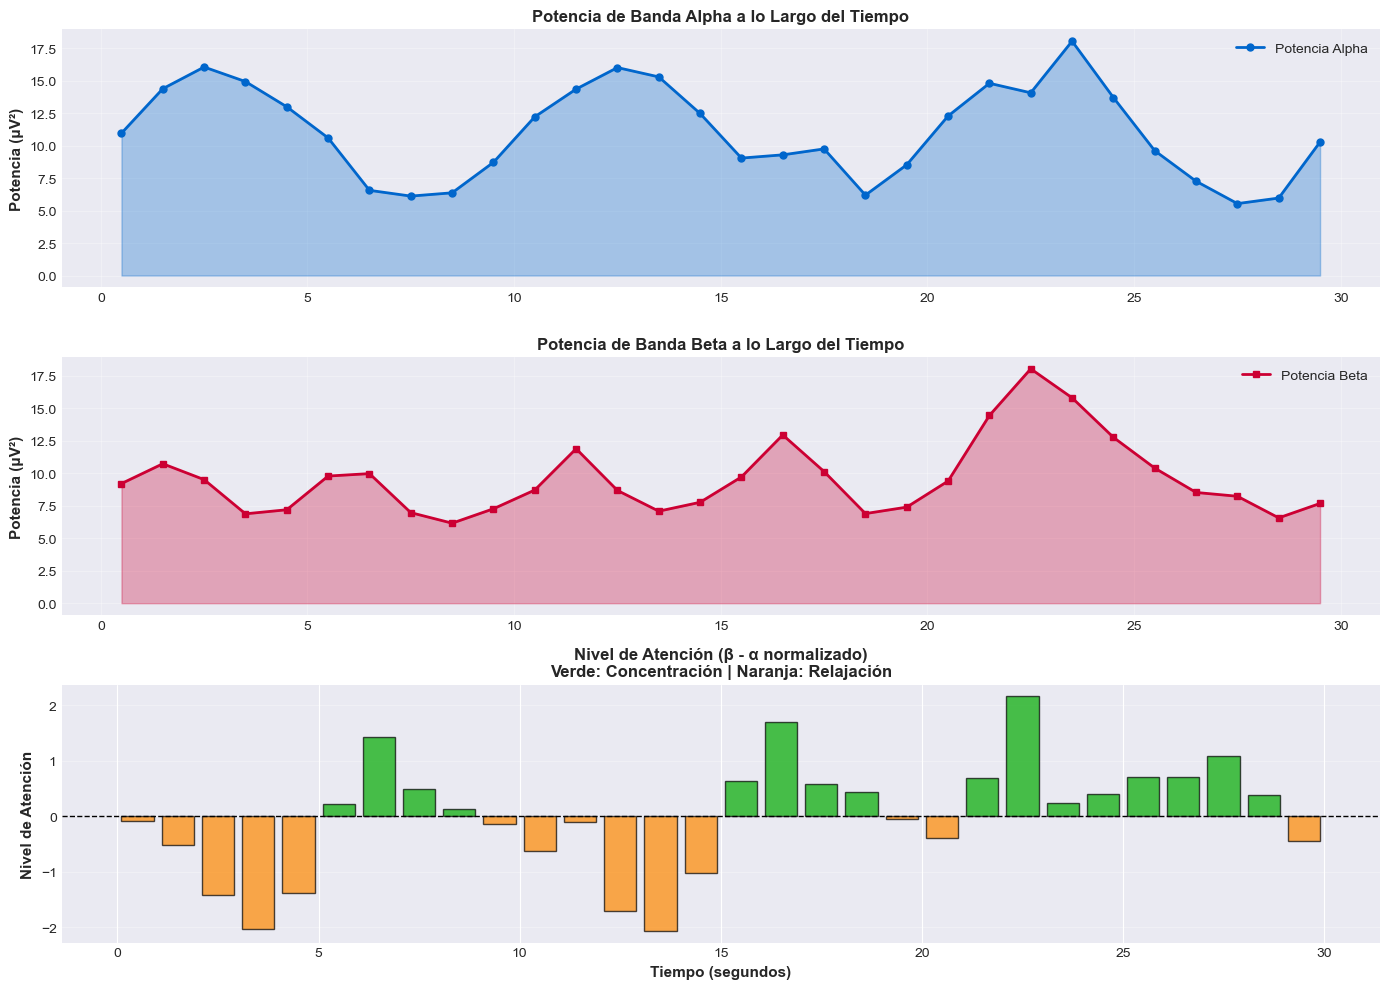

✅ Visualización de características completada


In [8]:
# Visualizar características extraídas
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Potencia Alpha
axes[0].plot(features_df['time'], features_df['alpha_power'], 
             color='#0066CC', marker='o', markersize=5, linewidth=2, label='Potencia Alpha')
axes[0].fill_between(features_df['time'], features_df['alpha_power'], alpha=0.3, color='#0066CC')
axes[0].set_ylabel('Potencia (μV²)', fontsize=11, fontweight='bold')
axes[0].set_title('Potencia de Banda Alpha a lo Largo del Tiempo', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='upper right')

# Potencia Beta
axes[1].plot(features_df['time'], features_df['beta_power'], 
             color='#CC0033', marker='s', markersize=5, linewidth=2, label='Potencia Beta')
axes[1].fill_between(features_df['time'], features_df['beta_power'], alpha=0.3, color='#CC0033')
axes[1].set_ylabel('Potencia (μV²)', fontsize=11, fontweight='bold')
axes[1].set_title('Potencia de Banda Beta a lo Largo del Tiempo', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='upper right')

# Nivel de Atención
colors = ['#00AA00' if x > 0 else '#FF8800' for x in features_df['attention_level']]
axes[2].bar(features_df['time'], features_df['attention_level'], color=colors, 
            alpha=0.7, width=0.8, edgecolor='black', linewidth=1)
axes[2].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[2].set_xlabel('Tiempo (segundos)', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Nivel de Atención', fontsize=11, fontweight='bold')
axes[2].set_title('Nivel de Atención (β - α normalizado)\nVerde: Concentración | Naranja: Relajación', 
                  fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("✅ Visualización de características completada")

## 7️⃣ Lógica de Control (Umbralización y Detección de Eventos)

La **lógica de control** traduce características de la señal en eventos binarios:
- **Si Potencia Alpha > Umbral**: Estado "RELAJADO" → Acción Visual 1
- **Si Potencia Beta > Umbral**: Estado "CONCENTRADO" → Acción Visual 2
- **Si Atención > Umbral**: Evento "ACTIVO" → Acción Visual 3

**Estrategias de umbralización:**
1. **Umbral fijo**: Valor constante predefinido
2. **Umbral adaptativo**: Se ajusta según estadísticas de la sesión
3. **Detección de cambios**: Compara con línea base

In [9]:
# Definir umbrales (puedes modificar estos valores)
print("=" * 60)
print("⚙️  DEFINIR UMBRALES DE CONTROL")
print("=" * 60)

# Umbrales para potencia bruta
THRESHOLD_ALPHA = features_df['alpha_power'].mean()
THRESHOLD_BETA = features_df['beta_power'].mean()

# Umbral para nivel de atención (normalizado)
THRESHOLD_ATTENTION = 0.5

print(f"\n📊 Estadísticas de Características:")
print(f"  Alpha Power - Media: {features_df['alpha_power'].mean():.2f}, Std: {features_df['alpha_power'].std():.2f}")
print(f"  Beta Power  - Media: {features_df['beta_power'].mean():.2f}, Std: {features_df['beta_power'].std():.2f}")
print(f"  Attention   - Media: {features_df['attention_level'].mean():.2f}, Std: {features_df['attention_level'].std():.2f}")

print(f"\n🎚️  Umbrales Configurados:")
print(f"  ✓ Umbral Alpha: {THRESHOLD_ALPHA:.2f} μV²")
print(f"  ✓ Umbral Beta: {THRESHOLD_BETA:.2f} μV²")
print(f"  ✓ Umbral Atención: {THRESHOLD_ATTENTION:.2f}")

# Función para detectar eventos
def detect_events(features_df, threshold_alpha, threshold_beta, threshold_attention):
    """
    Detectar eventos basados en umbrales
    
    Estados:
    0: Sin actividad
    1: Relajado (Alpha activo)
    2: Concentrado (Beta activo)
    3: Muy activo (Atención alta)
    """
    events = []
    states = []
    
    for idx, row in features_df.iterrows():
        event = 0
        state = "INACTIVO"
        
        if row['attention_level'] > threshold_attention:
            event = 3
            state = "MUY ACTIVO (Concentración Extrema)"
        elif row['beta_power'] > threshold_beta:
            event = 2
            state = "CONCENTRADO (Beta Dominante)"
        elif row['alpha_power'] > threshold_alpha:
            event = 1
            state = "RELAJADO (Alpha Dominante)"
        else:
            event = 0
            state = "INACTIVO"
        
        events.append(event)
        states.append(state)
    
    return events, states

# Detectar eventos
events, states = detect_events(features_df, THRESHOLD_ALPHA, THRESHOLD_BETA, THRESHOLD_ATTENTION)
features_df['event'] = events
features_df['state'] = states

print(f"\n✅ Eventos Detectados:")
event_counts = features_df['state'].value_counts()
for state, count in event_counts.items():
    percentage = (count / len(features_df)) * 100
    print(f"  • {state}: {count} ventanas ({percentage:.1f}%)")

⚙️  DEFINIR UMBRALES DE CONTROL

📊 Estadísticas de Características:
  Alpha Power - Media: 11.09, Std: 3.61
  Beta Power  - Media: 9.55, Std: 2.87
  Attention   - Media: 0.00, Std: 1.04

🎚️  Umbrales Configurados:
  ✓ Umbral Alpha: 11.09 μV²
  ✓ Umbral Beta: 9.55 μV²
  ✓ Umbral Atención: 0.50

✅ Eventos Detectados:
  • MUY ACTIVO (Concentración Extrema): 9 ventanas (30.0%)
  • INACTIVO: 8 ventanas (26.7%)
  • RELAJADO (Alpha Dominante): 8 ventanas (26.7%)
  • CONCENTRADO (Beta Dominante): 5 ventanas (16.7%)


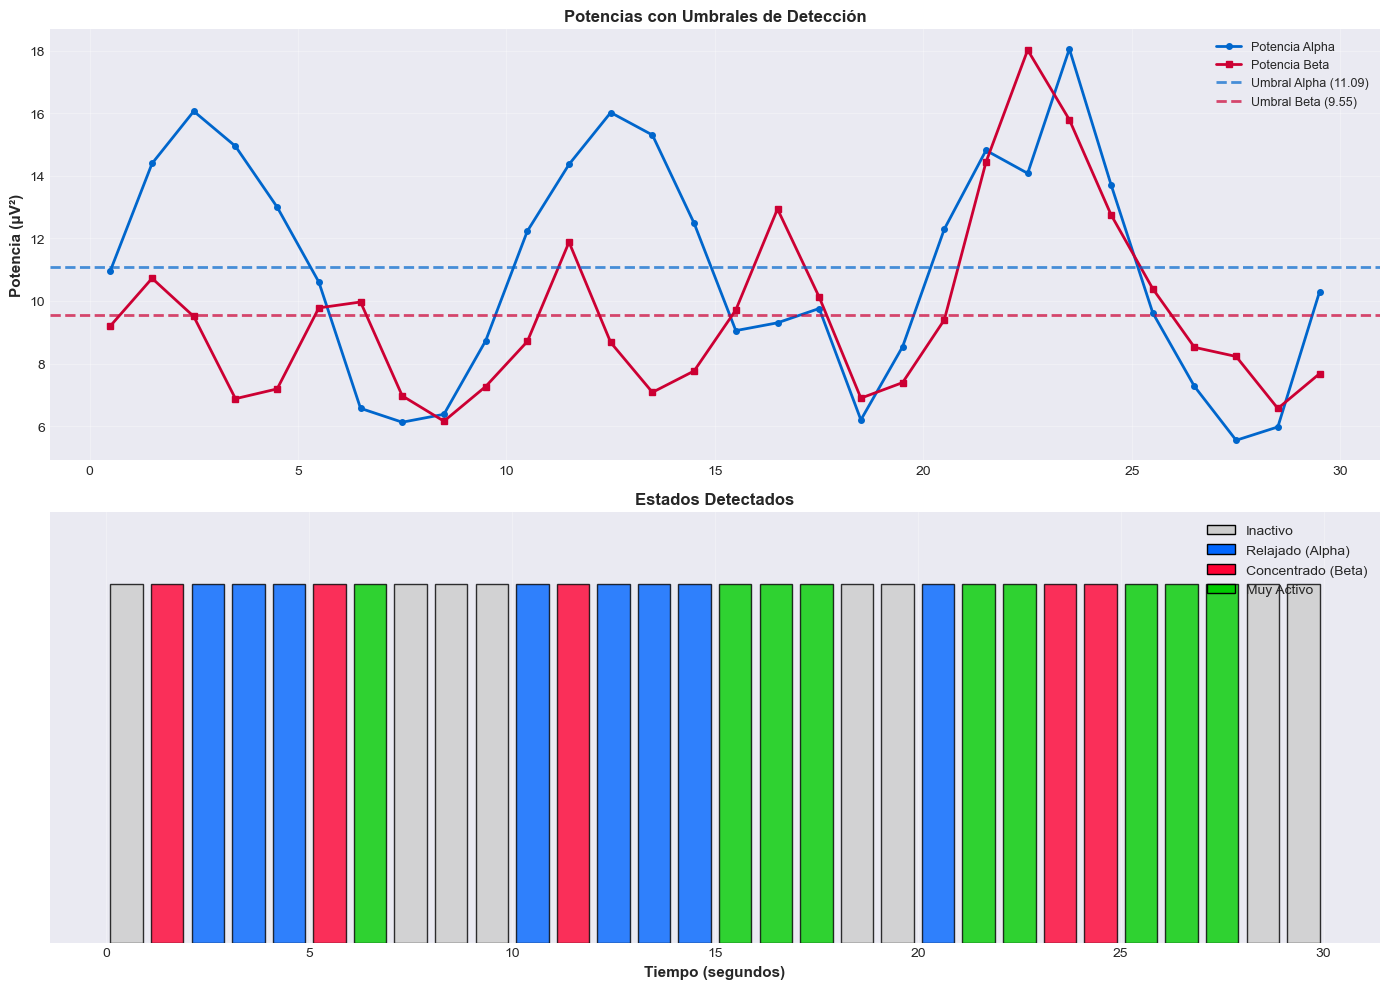

✅ Visualización de eventos completada


In [10]:
# Visualizar eventos detectados con umbrales
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Gráfico 1: Potencia con umbrales
axes[0].plot(features_df['time'], features_df['alpha_power'], 
             color='#0066CC', marker='o', markersize=4, linewidth=2, label='Potencia Alpha')
axes[0].plot(features_df['time'], features_df['beta_power'], 
             color='#CC0033', marker='s', markersize=4, linewidth=2, label='Potencia Beta')
axes[0].axhline(y=THRESHOLD_ALPHA, color='#0066CC', linestyle='--', linewidth=2, 
                alpha=0.7, label=f'Umbral Alpha ({THRESHOLD_ALPHA:.2f})')
axes[0].axhline(y=THRESHOLD_BETA, color='#CC0033', linestyle='--', linewidth=2, 
                alpha=0.7, label=f'Umbral Beta ({THRESHOLD_BETA:.2f})')
axes[0].set_ylabel('Potencia (μV²)', fontsize=11, fontweight='bold')
axes[0].set_title('Potencias con Umbrales de Detección', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='upper right', fontsize=9)

# Gráfico 2: Estados y eventos detectados
event_colors = {0: '#CCCCCC', 1: '#0066FF', 2: '#FF0033', 3: '#00CC00'}
colors = [event_colors[e] for e in features_df['event']]

axes[1].bar(features_df['time'], [1]*len(features_df), color=colors, 
            alpha=0.8, width=0.8, edgecolor='black', linewidth=1)
axes[1].set_xlabel('Tiempo (segundos)', fontsize=11, fontweight='bold')
axes[1].set_ylim(0, 1.2)
axes[1].set_yticks([])
axes[1].set_title('Estados Detectados', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

# Agregar leyenda
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#CCCCCC', edgecolor='black', label='Inactivo'),
    Patch(facecolor='#0066FF', edgecolor='black', label='Relajado (Alpha)'),
    Patch(facecolor='#FF0033', edgecolor='black', label='Concentrado (Beta)'),
    Patch(facecolor='#00CC00', edgecolor='black', label='Muy Activo')
]
axes[1].legend(handles=legend_elements, loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

print("✅ Visualización de eventos completada")

## 8️⃣ Respuesta Visual Interactiva

Implementaremos un **dashboard interactivo** que traduce estados cerebrales en respuestas visuales:

### Indicadores Visuales:
1. **Barra de Actividad**: Nivel de atención en tiempo real
2. **Indicador de Color**: Diferentes colores según el estado
3. **Contador de Eventos**: Registra activaciones
4. **Gráficos en Vivo**: Actualización de potencia y características

### Mapeo de Estados:
- **Inactivo** → Gris (sin actividad)
- **Relajado** → Azul (Alpha dominante)
- **Concentrado** → Rojo (Beta dominante)
- **Muy Activo** → Verde (Concentración extrema)

In [11]:
import tkinter as tk
from tkinter import Canvas
import threading
import time

# Función para crear interfaz visual con tkinter
def create_bci_visual_interface(features_df):
    """
    Crear interfaz visual interactiva con Tkinter
    """
    
    root = tk.Tk()
    root.title("🧠 BCI Simulado - Control Visual")
    root.geometry("1200x700")
    root.configure(bg='#1a1a1a')
    
    # Colores para estados
    color_map = {
        0: '#CCCCCC',  # Inactivo
        1: '#0066FF',  # Relajado
        2: '#FF0033',  # Concentrado
        3: '#00CC00'   # Muy Activo
    }
    
    state_labels = {
        0: "⚪ INACTIVO",
        1: "🔵 RELAJADO",
        2: "🔴 CONCENTRADO",
        3: "🟢 MUY ACTIVO"
    }
    
    # Panel superior: Información general
    info_frame = tk.Frame(root, bg='#2a2a2a', height=80)
    info_frame.pack(fill=tk.X, padx=10, pady=10)
    
    title_label = tk.Label(info_frame, text="🧠 BCI Simulado - Control Visual en Tiempo Real", 
                          font=("Arial", 16, "bold"), fg='white', bg='#2a2a2a')
    title_label.pack()
    
    status_label = tk.Label(info_frame, text="Información de Sesión", 
                           font=("Arial", 11), fg='#AAAAAA', bg='#2a2a2a')
    status_label.pack()
    
    # Panel central: Indicadores visuales
    indicator_frame = tk.Frame(root, bg='#1a1a1a')
    indicator_frame.pack(fill=tk.BOTH, expand=True, padx=10, pady=10)
    
    # Crear canvas para animación
    canvas = Canvas(indicator_frame, bg='#1a1a1a', height=300, highlightthickness=0)
    canvas.pack(fill=tk.X, pady=10)
    
    # Panel inferior: Estadísticas
    stats_frame = tk.Frame(root, bg='#2a2a2a', height=150)
    stats_frame.pack(fill=tk.X, padx=10, pady=10)
    
    stats_text = tk.Label(stats_frame, text="Estadísticas de Sesión", 
                         font=("Arial", 12, "bold"), fg='white', bg='#2a2a2a', justify=tk.LEFT)
    stats_text.pack(anchor=tk.W, padx=10, pady=5)
    
    # Función de actualización
    current_idx = [0]
    event_counter = {0: 0, 1: 0, 2: 0, 3: 0}
    
    def update_visualization():
        if current_idx[0] >= len(features_df):
            root.after(100, update_visualization)
            return
        
        row = features_df.iloc[current_idx[0]]
        event = row['event']
        attention = row['attention_level']
        alpha = row['alpha_power']
        beta = row['beta_power']
        
        event_counter[event] += 1
        
        # Actualizar canvas
        canvas.delete("all")
        
        # Dibujar círculo indicador
        indicator_color = color_map[int(event)]
        circle_x, circle_y = 100, 150
        circle_size = 60
        canvas.create_oval(circle_x - circle_size, circle_y - circle_size,
                          circle_x + circle_size, circle_y + circle_size,
                          fill=indicator_color, outline='white', width=3)
        
        canvas.create_text(circle_x, circle_y, text=state_labels[int(event)],
                          font=("Arial", 12, "bold"), fill='white')
        
        # Barra de atención
        bar_x, bar_y = 300, 150
        bar_width = 300
        bar_height = 30
        
        # Fondo de barra
        canvas.create_rectangle(bar_x, bar_y - bar_height//2,
                               bar_x + bar_width, bar_y + bar_height//2,
                               fill='#333333', outline='white', width=2)
        
        # Barra de progreso
        filled_width = max(0, (attention + 2) * bar_width / 4)  # Normalizar
        filled_width = min(filled_width, bar_width)
        
        bar_color = '#FF0033' if attention > 0 else '#0066FF'
        canvas.create_rectangle(bar_x, bar_y - bar_height//2,
                               bar_x + filled_width, bar_y + bar_height//2,
                               fill=bar_color, outline='none')
        
        canvas.create_text(bar_x + bar_width/2, bar_y, 
                          text=f"Atención: {attention:.2f}",
                          font=("Arial", 10), fill='white')
        
        # Información de potencia
        info_x, info_y = 700, 100
        canvas.create_text(info_x, info_y, text=f"Alpha Power: {alpha:.2f} μV²",
                          font=("Arial", 10), fill='#0066FF', anchor='w')
        canvas.create_text(info_x, info_y + 30, text=f"Beta Power: {beta:.2f} μV²",
                          font=("Arial", 10), fill='#FF0033', anchor='w')
        canvas.create_text(info_x, info_y + 60, text=f"Tiempo: {row['time']:.1f}s",
                          font=("Arial", 10), fill='#AAAAAA', anchor='w')
        
        # Actualizar estadísticas
        total_events = sum(event_counter.values())
        stats_text.config(text=(
            f"Eventos Totales: {total_events} | "
            f"Inactivo: {event_counter[0]} | "
            f"Relajado: {event_counter[1]} | "
            f"Concentrado: {event_counter[2]} | "
            f"Muy Activo: {event_counter[3]} | "
            f"Progreso: {current_idx[0]+1}/{len(features_df)}"
        ))
        
        current_idx[0] += 1
        root.after(100, update_visualization)
    
    # Iniciar actualización
    update_visualization()
    
    # Botón de salida
    quit_btn = tk.Button(root, text="Salir", command=root.quit,
                        bg='#CC0033', fg='white', font=("Arial", 10, "bold"),
                        padx=20, pady=10)
    quit_btn.pack(side=tk.BOTTOM, pady=10)
    
    root.mainloop()

# Ejecutar interfaz visual
print("\n" + "="*60)
print("🎨 INICIANDO INTERFAZ VISUAL INTERACTIVA")
print("="*60)
print("Se abrirá una ventana con la simulación de BCI...")
print("Cierre la ventana cuando haya terminado de ver la simulación.")

# Descomenta la línea siguiente para ejecutar la interfaz (puede no funcionar en algunos entornos)
# create_bci_visual_interface(features_df)

print("✅ Código de visualización interactiva disponible")


🎨 INICIANDO INTERFAZ VISUAL INTERACTIVA
Se abrirá una ventana con la simulación de BCI...
Cierre la ventana cuando haya terminado de ver la simulación.
✅ Código de visualización interactiva disponible


## 9️⃣ Dashboard Completo - Visualización Integrada

Este dashboard integra todos los componentes del sistema BCI:
1. **Señal en tiempo real**: Visualización de la señal EEG
2. **Potencias de banda**: Alpha y Beta normalizadas
3. **Eventos detectados**: Estados y transiciones
4. **Indicadores de control**: Respuesta del sistema
5. **Estadísticas**: Resumen de sesión

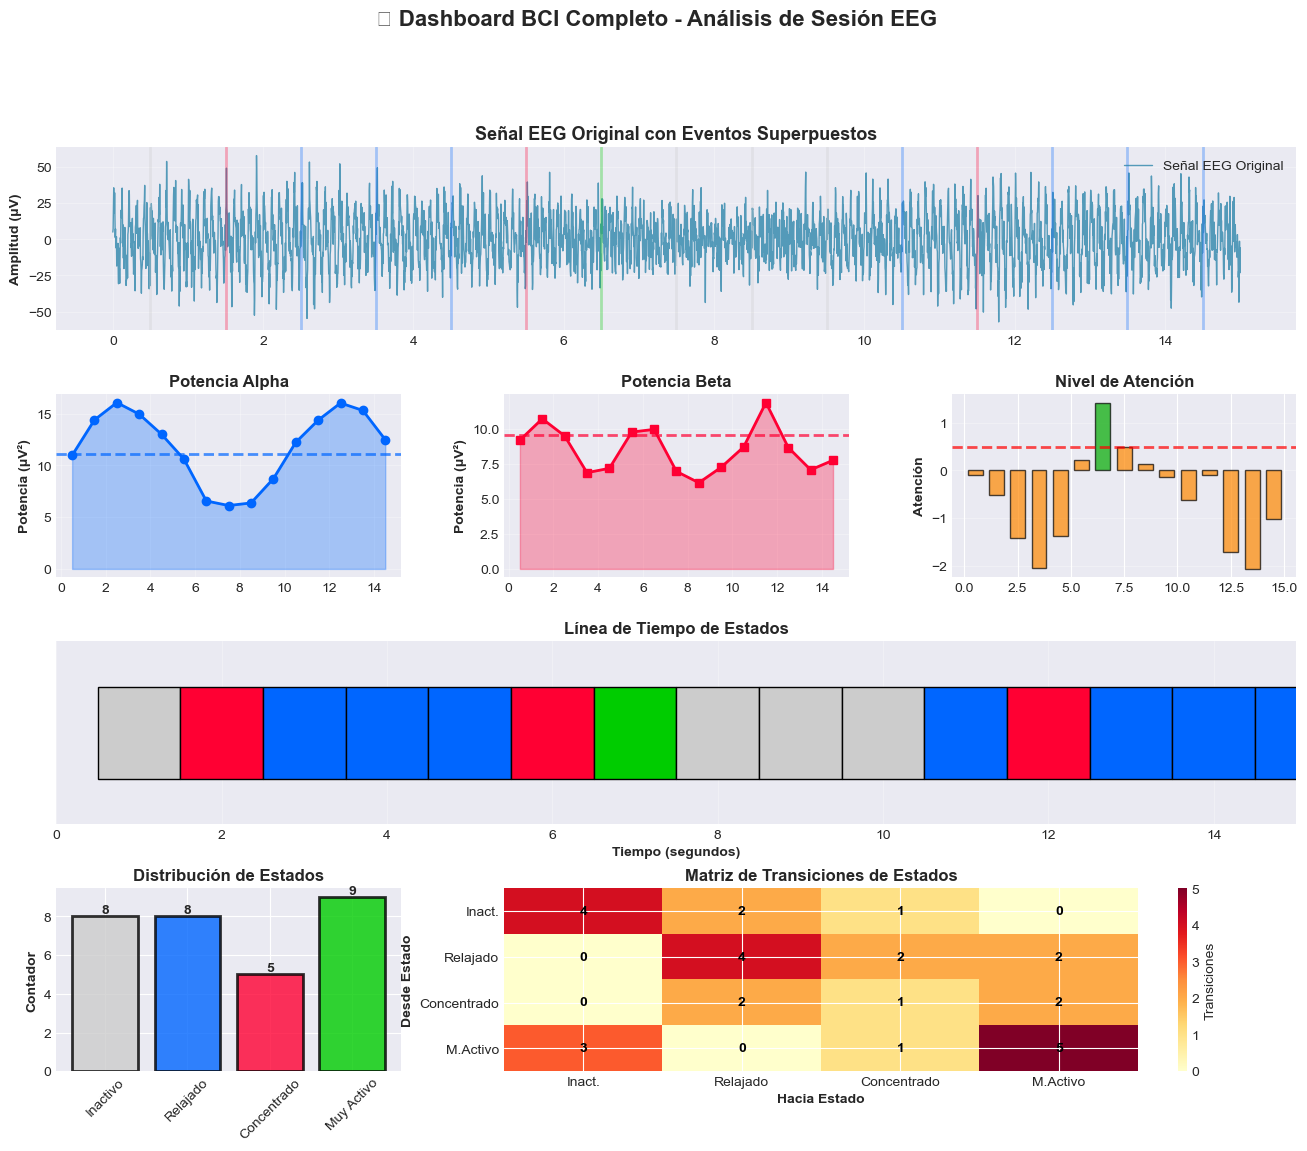

✅ Dashboard completo visualizado


In [12]:
# Crear dashboard completo
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(4, 3, hspace=0.35, wspace=0.3)

# 1. Señal EEG original con eventos
ax1 = fig.add_subplot(gs[0, :])
time_limit = 15
mask_plot = data['time'] <= time_limit
ax1.plot(data[mask_plot]['time'], data[mask_plot]['amplitude'], 
         color='#2E86AB', linewidth=1, label='Señal EEG Original', alpha=0.8)
ax1.set_ylabel('Amplitud (μV)', fontweight='bold')
ax1.set_title('Señal EEG Original con Eventos Superpuestos', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right')

# Superponer eventos
mask_features = features_df['time'] <= time_limit
for idx, row in features_df[mask_features].iterrows():
    event_time = row['time']
    event_color = ['#CCCCCC', '#0066FF', '#FF0033', '#00CC00'][int(row['event'])]
    ax1.axvline(x=event_time, color=event_color, alpha=0.3, linewidth=2)

# 2. Potencia Alpha
ax2 = fig.add_subplot(gs[1, 0])
mask_features = features_df['time'] <= time_limit
ax2.plot(features_df[mask_features]['time'], features_df[mask_features]['alpha_power'], 
         color='#0066FF', marker='o', markersize=6, linewidth=2)
ax2.axhline(y=THRESHOLD_ALPHA, color='#0066FF', linestyle='--', linewidth=2, alpha=0.7)
ax2.fill_between(features_df[mask_features]['time'], 
                 features_df[mask_features]['alpha_power'], alpha=0.3, color='#0066FF')
ax2.set_ylabel('Potencia (μV²)', fontweight='bold')
ax2.set_title('Potencia Alpha', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

# 3. Potencia Beta
ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(features_df[mask_features]['time'], features_df[mask_features]['beta_power'], 
         color='#FF0033', marker='s', markersize=6, linewidth=2)
ax3.axhline(y=THRESHOLD_BETA, color='#FF0033', linestyle='--', linewidth=2, alpha=0.7)
ax3.fill_between(features_df[mask_features]['time'], 
                 features_df[mask_features]['beta_power'], alpha=0.3, color='#FF0033')
ax3.set_ylabel('Potencia (μV²)', fontweight='bold')
ax3.set_title('Potencia Beta', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)

# 4. Nivel de Atención
ax4 = fig.add_subplot(gs[1, 2])
colors_attention = ['#00AA00' if x > THRESHOLD_ATTENTION else '#FF8800' 
                    for x in features_df[mask_features]['attention_level']]
ax4.bar(features_df[mask_features]['time'], 
        features_df[mask_features]['attention_level'],
        color=colors_attention, alpha=0.7, width=0.7, edgecolor='black', linewidth=1)
ax4.axhline(y=THRESHOLD_ATTENTION, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax4.set_ylabel('Atención', fontweight='bold')
ax4.set_title('Nivel de Atención', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')

# 5. Estados (representación temporal)
ax5 = fig.add_subplot(gs[2, :])
event_colors = ['#CCCCCC', '#0066FF', '#FF0033', '#00CC00']
for idx, row in features_df[mask_features].iterrows():
    event_color = event_colors[int(row['event'])]
    ax5.barh(0, 1, left=row['time'], color=event_color, height=0.5, 
             edgecolor='black', linewidth=1)
ax5.set_ylim(-0.5, 0.5)
ax5.set_xlim(0, time_limit)
ax5.set_yticks([])
ax5.set_xlabel('Tiempo (segundos)', fontweight='bold')
ax5.set_title('Línea de Tiempo de Estados', fontsize=12, fontweight='bold')
ax5.grid(True, alpha=0.3, axis='x')

# 6. Histograma de eventos
ax6 = fig.add_subplot(gs[3, 0])
state_names = ['Inactivo', 'Relajado', 'Concentrado', 'Muy Activo']
state_counts = [
    (features_df['event'] == 0).sum(),
    (features_df['event'] == 1).sum(),
    (features_df['event'] == 2).sum(),
    (features_df['event'] == 3).sum()
]
bars = ax6.bar(state_names, state_counts, color=['#CCCCCC', '#0066FF', '#FF0033', '#00CC00'],
               edgecolor='black', linewidth=2, alpha=0.8)
ax6.set_ylabel('Contador', fontweight='bold')
ax6.set_title('Distribución de Estados', fontsize=12, fontweight='bold')
ax6.tick_params(axis='x', rotation=45)
for bar in bars:
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom', fontweight='bold')

# 7. Matriz de transiciones de estados
ax7 = fig.add_subplot(gs[3, 1:])
transition_matrix = np.zeros((4, 4))
for i in range(len(features_df) - 1):
    from_state = int(features_df.iloc[i]['event'])
    to_state = int(features_df.iloc[i+1]['event'])
    transition_matrix[from_state, to_state] += 1

im = ax7.imshow(transition_matrix, cmap='YlOrRd', aspect='auto')
ax7.set_xticks(range(4))
ax7.set_yticks(range(4))
ax7.set_xticklabels(['Inact.', 'Relajado', 'Concentrado', 'M.Activo'])
ax7.set_yticklabels(['Inact.', 'Relajado', 'Concentrado', 'M.Activo'])
ax7.set_xlabel('Hacia Estado', fontweight='bold')
ax7.set_ylabel('Desde Estado', fontweight='bold')
ax7.set_title('Matriz de Transiciones de Estados', fontsize=12, fontweight='bold')

# Agregar valores en la matriz
for i in range(4):
    for j in range(4):
        text = ax7.text(j, i, f'{int(transition_matrix[i, j])}',
                       ha="center", va="center", color="black", fontweight='bold')

plt.colorbar(im, ax=ax7, label='Transiciones')

# Título general
fig.suptitle('🧠 Dashboard BCI Completo - Análisis de Sesión EEG', 
             fontsize=16, fontweight='bold', y=0.995)

plt.show()

print("✅ Dashboard completo visualizado")